<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L1_bounty_viz_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
import pandas as pd
df = pd.read_pickle('https://github.com/nepslor/teaching/raw/refs/heads/main/CAS_BDML/bounty_data.pk')

In [2]:
df

,x,y
2024-01-01 00:00:00,NaN,NaN
2024-01-01 01:00:00,NaN,NaN
2024-01-01 02:00:00,-394.12,-51.12
2024-01-01 03:00:00,NaN,NaN
2024-01-01 04:00:00,NaN,NaN
...,...,...
2027-07-19 05:00:00,NaN,NaN
2027-07-19 06:00:00,-1643.48,-1293.48
2027-07-19 07:00:00,-1642.52,-1293.52
2027-07-19 08:00:00,NaN,NaN


<Axes: >

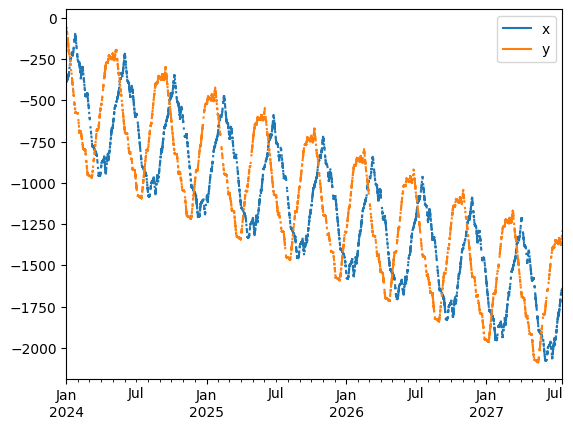

In [3]:
df.plot()

<Axes: xlabel='x', ylabel='y'>

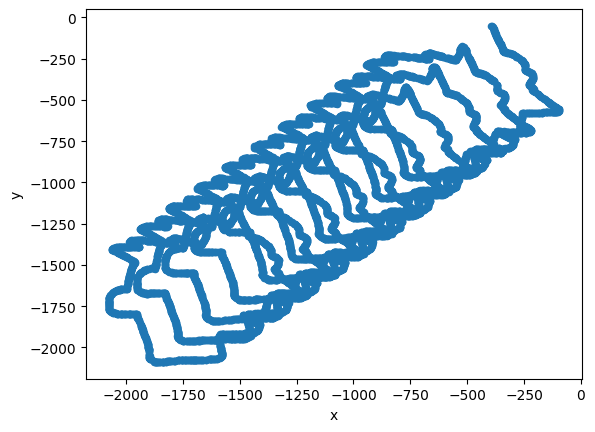

In [63]:
df.plot.scatter(x=0, y=1)

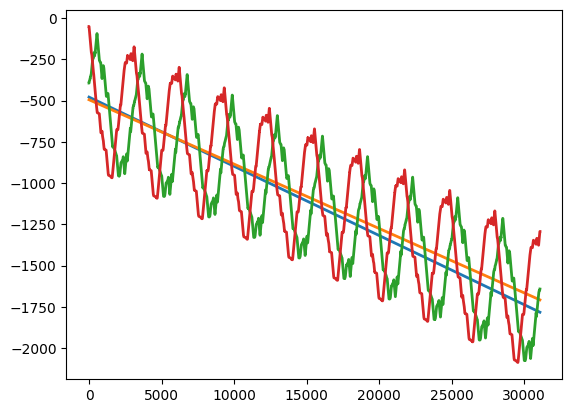

In [58]:
import numpy as np
import matplotlib.pyplot as plt
df_i = df.interpolate(method='linear').bfill()
Y = df_i.to_numpy()
X = np.column_stack([np.ones_like(t), t]) # [1, t]

# fit all columns at once: Y ~ beta0 + beta1*tY = df_i.to_numpy()
B, *_ = np.linalg.lstsq(X, Y, rcond=None) # shape: (2, n_series)

# fitted values on original scaleY_hat = X @ Bplt.plot(Y, alpha=0.5)
Y_hat = X @ B
plt.plot(Y_hat, linewidth=2)
plt.plot(df_i.to_numpy(), linewidth=2)
plt.show()

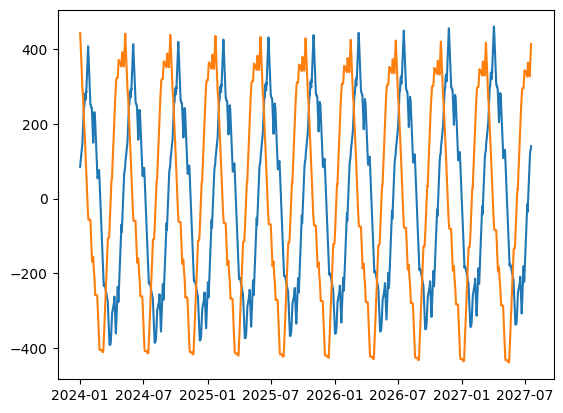

In [59]:
plt.plot(df_i - Y_hat)

<Axes: xlabel='x', ylabel='y'>

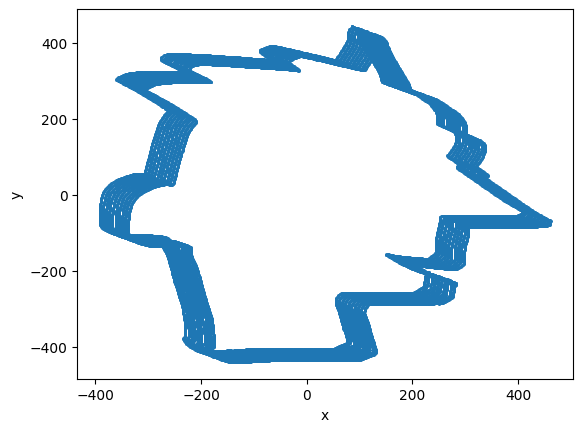

In [64]:
(df_i - Y_hat).plot.scatter(x=0, y=1, s=1)